In [2]:
import pandas as pd
import numpy as np

In [76]:
# url= "ncr_ride_bookings.csv"
# df = pd.read_csv(url, sep=";", encoding="utf-8")
# # df = pd.read_csv(url, sep=";", encoding="utf-8", index_col=0)
# df.head()


import pandas as pd

df = pd.read_csv(
    "ncr_ride_bookings.csv",
    sep=",",
    quotechar='"',
    encoding="utf-8"
)

print(df.columns.tolist())

['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID', 'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT', 'Avg CTAT', 'Cancelled Rides by Customer', 'Reason for cancelling by Customer', 'Cancelled Rides by Driver', 'Driver Cancellation Reason', 'Incomplete Rides', 'Incomplete Rides Reason', 'Booking Value', 'Ride Distance', 'Driver Ratings', 'Customer Rating', 'Payment Method']


## fix ID  "Booking ID", "Customer ID"


In [77]:
id_cols = ["Booking ID", "Customer ID"]

for col in id_cols:
    df[col] = df[col].str.replace('"', '', regex=False).str.strip()

In [35]:
print(df.head())

         Date      Time  Booking ID   Booking Status Customer ID  \
0  2024-03-23  12:29:38  CNR5884300  No Driver Found  CID1982111   
1  2024-11-29  18:01:39  CNR1326809       Incomplete  CID4604802   
2  2024-08-23  08:56:10  CNR8494506        Completed  CID9202816   
3  2024-10-21  17:17:25  CNR8906825        Completed  CID2610914   
4  2024-09-16  22:08:00  CNR1950162        Completed  CID9933542   

    Vehicle Type      Pickup Location      Drop Location  Avg VTAT  Avg CTAT  \
0          eBike          Palam Vihar            Jhilmil       NaN       NaN   
1       Go Sedan        Shastri Nagar  Gurgaon Sector 56       4.9      14.0   
2           Auto              Khandsa      Malviya Nagar      13.4      25.8   
3  Premier Sedan  Central Secretariat           Inderlok      13.1      28.5   
4           Bike     Ghitorni Village        Khan Market       5.3      19.6   

   ...  Reason for cancelling by Customer Cancelled Rides by Driver  \
0  ...                                N

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [36]:
print(df.columns)


Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')


## separe les df de 3 dataframe columns

In [78]:
booking_cols = [
    "Date",
    "Time",
    "Booking ID",
    "Booking Status",
    "Customer ID",
    "Vehicle Type"
]

ride_cols = [
        "Booking ID",
    "Pickup Location",
    "Drop Location",
    "Ride Distance",
    "Booking Value",
    "Payment Method"
]

performance_cols = [
    "Booking ID",
    "Avg VTAT",
    "Avg CTAT",
    "Driver Ratings",
    "Customer Rating",
    "Cancelled Rides by Customer",
    "Cancelled Rides by Driver",
    "Incomplete Rides"
]


df_booking = df[booking_cols]

df_ride = df[ride_cols]

df_performance = df[performance_cols]
print(df_booking.head())

         Date      Time  Booking ID   Booking Status Customer ID  \
0  2024-03-23  12:29:38  CNR5884300  No Driver Found  CID1982111   
1  2024-11-29  18:01:39  CNR1326809       Incomplete  CID4604802   
2  2024-08-23  08:56:10  CNR8494506        Completed  CID9202816   
3  2024-10-21  17:17:25  CNR8906825        Completed  CID2610914   
4  2024-09-16  22:08:00  CNR1950162        Completed  CID9933542   

    Vehicle Type  
0          eBike  
1       Go Sedan  
2           Auto  
3  Premier Sedan  
4           Bike  


In [40]:
print(df_ride.head())

   Booking ID      Pickup Location      Drop Location  Ride Distance  \
0  CNR5884300          Palam Vihar            Jhilmil            NaN   
1  CNR1326809        Shastri Nagar  Gurgaon Sector 56           5.73   
2  CNR8494506              Khandsa      Malviya Nagar          13.58   
3  CNR8906825  Central Secretariat           Inderlok          34.02   
4  CNR1950162     Ghitorni Village        Khan Market          48.21   

   Booking Value Payment Method  
0            NaN            NaN  
1          237.0            UPI  
2          627.0     Debit Card  
3          416.0            UPI  
4          737.0            UPI  


In [39]:
print(df_performance.head())

   Booking ID  Avg VTAT  Avg CTAT  Driver Ratings  Customer Rating  \
0  CNR5884300       NaN       NaN             NaN              NaN   
1  CNR1326809       4.9      14.0             NaN              NaN   
2  CNR8494506      13.4      25.8             4.9              4.9   
3  CNR8906825      13.1      28.5             4.6              5.0   
4  CNR1950162       5.3      19.6             4.1              4.3   

   Cancelled Rides by Customer  Cancelled Rides by Driver  Incomplete Rides  
0                          NaN                        NaN               NaN  
1                          NaN                        NaN               1.0  
2                          NaN                        NaN               NaN  
3                          NaN                        NaN               NaN  
4                          NaN                        NaN               NaN  


In [79]:
df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

## Conversion des colonnes numériques

In [51]:
df["Avg VTAT"].dtype

dtype('float64')

In [81]:
num_cols = [
    "Avg VTAT",
    "Avg CTAT",
    "Booking Value",
    "Ride Distance",
    "Driver Ratings",
    "Customer Rating"
]
# type(df["Avg VTAT"])


for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    # print(df.head(5).to_string())

In [83]:
df["Booking Status"]

0         No Driver Found
1              Incomplete
2               Completed
3               Completed
4               Completed
               ...       
149995          Completed
149996          Completed
149997          Completed
149998          Completed
149999          Completed
Name: Booking Status, Length: 150000, dtype: object

In [82]:
df.dtypes

Date                                  object
Time                                  object
Booking ID                            object
Booking Status                        object
Customer ID                           object
Vehicle Type                          object
Pickup Location                       object
Drop Location                         object
Avg VTAT                             float64
Avg CTAT                             float64
Cancelled Rides by Customer          float64
Reason for cancelling by Customer     object
Cancelled Rides by Driver            float64
Driver Cancellation Reason            object
Incomplete Rides                     float64
Incomplete Rides Reason               object
Booking Value                        float64
Ride Distance                        float64
Driver Ratings                       float64
Customer Rating                      float64
Payment Method                        object
dtype: object

In [69]:
type(df["Avg VTAT"])

pandas.core.series.Series

In [72]:
df["Avg VTAT"].dtype

dtype('float64')

In [71]:
df["Booking ID"].dtype

dtype('O')

In [46]:
df.isna().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

<Axes: ylabel='count'>

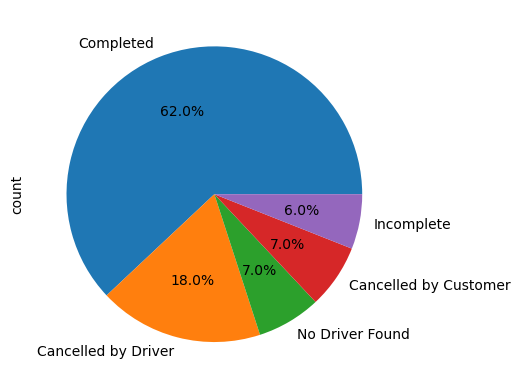

In [48]:
df["Booking Status"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)